## Carolina Queiroz de Sousa

Email: cqs@cesar.school

Dataset: https://github.com/Carolqsousa/RNA-e-Deep-Learning---CESAR-School-2025.01/blob/main/Trabalho%20Final/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xls


# (i) Carregamento do Dataset e manipulações

In [30]:
import pandas as pd


dataset_url = 'https://github.com/Carolqsousa/RNA-e-Deep-Learning---CESAR-School-2025.01/raw/main/Trabalho%20Final/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xls'

try:
    df = pd.read_excel(dataset_url)
    print("Dataset loaded successfully from GitHub into DataFrame 'df'.")
    print("First 5 rows of the dataset:")
    print(df.head())
    print(f"Shape of the dataset: {df.shape}")
except Exception as e:
    print(f"Error loading dataset from URL: {e}")
    df = None


Dataset loaded successfully from GitHub into DataFrame 'df'.
First 5 rows of the dataset:
    Area  Perimeter  Major_Axis  Minor_Axis  Eccentricity   Eqdiasq  Solidity  \
0  63391   1568.405    390.3396    236.7461        0.7951  284.0984    0.8665   
1  68358   1942.187    410.8594    234.7525        0.8207  295.0188    0.8765   
2  73589   1246.538    452.3630    220.5547        0.8731  306.0987    0.9172   
3  71106   1445.261    429.5291    216.0765        0.8643  300.8903    0.9589   
4  80087   1251.524    469.3783    220.9344        0.8823  319.3273    0.9657   

   Convex_Area  Extent  Aspect_Ratio  ...  StdDev_RR  StdDev_RG  StdDev_RB  \
0        73160  0.6394        1.6488  ...    17.7206    19.6024    21.1342   
1        77991  0.6772        1.7502  ...    26.7061    27.2112    25.1035   
2        80234  0.7127        2.0510  ...    19.0129    20.0703    20.7006   
3        74153  0.7028        1.9879  ...    18.1773    18.7152    29.7883   
4        82929  0.7459        2.1

## Preparar Dados para PyTorch




In [31]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 2. Convert X_train_scaled and X_test_scaled to PyTorch tensors of float32 type
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 3. Convert y_train and y_test to PyTorch tensors of float32 type
# Reshape y_train and y_test to have an additional dimension for binary compatibility
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")

# 4. Create a TensorDataset for the training set
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# 5. Create a TensorDataset for the test set
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print("TensorDatasets created for training and testing.")

# 6. Create a DataLoader for the training set with a batch_size of 32 and shuffle=True
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 7. Create a DataLoader for the test set with a batch_size of 32 and shuffle=False
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch_size={batch_size}.")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

X_train_tensor shape: torch.Size([1718, 28])
y_train_tensor shape: torch.Size([1718, 1])
X_test_tensor shape: torch.Size([430, 28])
y_test_tensor shape: torch.Size([430, 1])
TensorDatasets created for training and testing.
DataLoaders created with batch_size=32.
Number of batches in training loader: 54
Number of batches in test loader: 14


# (ii) Definição do modelo de redes neurais




In [32]:
import torch
import torch.nn as nn


class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output_layer(x)
        # For binary classification, typically sigmoid is applied in the loss function
        # or explicitly here if outputs are probabilities, but for this step, we just define layers.
        return x

# Instantiate the model
# input_dim is already available from previous steps (X_train_scaled.shape[1])
model_pytorch_v1 = SimpleNN(input_dim)

print("PyTorch Model Architecture (Version 1):")
print(model_pytorch_v1)
print("\nPyTorch model (Version 1) defined successfully!")

PyTorch Model Architecture (Version 1):
SimpleNN(
  (layer1): Linear(in_features=28, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

PyTorch model (Version 1) defined successfully!


# (iii) Treinamento do modelo




In [33]:
import torch.optim as optim

# 1. Instantiate the optimizer (Adam)
optimizer = optim.Adam(model_pytorch_v1.parameters(), lr=0.001)

# 2. Instantiate the loss function (BCEWithLogitsLoss)
criterion = nn.BCEWithLogitsLoss()

# 3. Define the number of epochs
epochs = 50

# 4. Create lists to store metrics
train_losses_pytorch = []
train_accuracies_pytorch = []
val_losses_pytorch = []
val_accuracies_pytorch = []

print(f"Iniciando o treinamento do modelo PyTorch (Versão 1) com {epochs} épocas...")

for epoch in range(epochs):
    # Training phase
    model_pytorch_v1.train()  # Set model to training mode
    current_train_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the gradients
        outputs = model_pytorch_v1(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        current_train_loss += loss.item() * inputs.size(0)

        # Calculate training accuracy
        predicted = torch.round(torch.sigmoid(outputs)) # Apply sigmoid and round for binary prediction
        correct_train_predictions += (predicted == labels).sum().item()
        total_train_samples += labels.size(0)

    epoch_train_loss = current_train_loss / total_train_samples
    epoch_train_accuracy = correct_train_predictions / total_train_samples

    # Evaluation phase
    model_pytorch_v1.eval()  # Set model to evaluation mode
    current_val_loss = 0.0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for inputs, labels in test_loader:
            outputs = model_pytorch_v1(inputs)
            loss = criterion(outputs, labels)
            current_val_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            predicted = torch.round(torch.sigmoid(outputs))
            correct_val_predictions += (predicted == labels).sum().item()
            total_val_samples += labels.size(0)

    epoch_val_loss = current_val_loss / total_val_samples
    epoch_val_accuracy = correct_val_predictions / total_val_samples

    # Store metrics
    train_losses_pytorch.append(epoch_train_loss)
    train_accuracies_pytorch.append(epoch_train_accuracy)
    val_losses_pytorch.append(epoch_val_loss)
    val_accuracies_pytorch.append(epoch_val_accuracy)

    # Print metrics for the current epoch
    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} - "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

print("\nTreinamento do modelo PyTorch (Versão 1) concluído!")

Iniciando o treinamento do modelo PyTorch (Versão 1) com 50 épocas...
Epoch 1/50 - Train Loss: 0.5388, Train Acc: 0.7980 - Val Loss: 0.3593, Val Acc: 0.8767
Epoch 2/50 - Train Loss: 0.2974, Train Acc: 0.8888 - Val Loss: 0.2826, Val Acc: 0.8860
Epoch 3/50 - Train Loss: 0.2661, Train Acc: 0.8993 - Val Loss: 0.2621, Val Acc: 0.8977
Epoch 4/50 - Train Loss: 0.2465, Train Acc: 0.9080 - Val Loss: 0.2551, Val Acc: 0.8953
Epoch 5/50 - Train Loss: 0.2406, Train Acc: 0.9121 - Val Loss: 0.2432, Val Acc: 0.8977
Epoch 6/50 - Train Loss: 0.2421, Train Acc: 0.9109 - Val Loss: 0.2306, Val Acc: 0.9093
Epoch 7/50 - Train Loss: 0.2247, Train Acc: 0.9144 - Val Loss: 0.2325, Val Acc: 0.9023
Epoch 8/50 - Train Loss: 0.2137, Train Acc: 0.9185 - Val Loss: 0.2218, Val Acc: 0.9070
Epoch 9/50 - Train Loss: 0.2031, Train Acc: 0.9237 - Val Loss: 0.2129, Val Acc: 0.9163
Epoch 10/50 - Train Loss: 0.2054, Train Acc: 0.9255 - Val Loss: 0.2097, Val Acc: 0.9140
Epoch 11/50 - Train Loss: 0.2051, Train Acc: 0.9267 - Val L

#(iv) Análise do modelo



###Análise do Modelo 1:

O treinamento do Modelo 1 foi realizado por 50 épocas fixas, utilizando uma arquitetura de rede neural densa com Dropout de 0.3. Ao final do treinamento, o modelo alcançou uma acurácia de 0.9465 e uma perda de 0.1764 no conjunto de teste. Sua matriz de confusão resultou em [[237 10], [13 170]], indicando um bom desempenho geral em termos de identificação correta das classes.

No entanto, ao analisar os gráficos de desempenho (acurácia e perda) durante o treinamento, foi observado um comportamento característico de overfitting. As curvas mostraram que, enquanto a acurácia de treinamento continuava a melhorar e a perda de treinamento a diminuir, a acurácia de validação tendia a se estabilizar ou flutuar, e a perda de validação parava de diminuir significativamente, e em alguns momentos até aumentava ligeiramente. Isso sugere que o modelo estava começando a se especializar excessivamente nos dados de treinamento, perdendo a capacidade de generalizar tão bem para dados novos e não vistos. Não foram identificadas grandes dificuldades técnicas ou desafios inesperados durante este processo inicial, sendo o principal ponto de atenção a tendência ao overfitting.

## Modelo Aprimorado (Com Dropout e Early Stopping)

###Esse modelo visa ajudar na questão do overfitting




In [34]:
import torch
import torch.nn as nn

# Define the PyTorch model class, similar to Keras V2
class SimpleNN_V2(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN_V2, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4) # Dropout rate increased to 0.4
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4) # Dropout rate increased to 0.4
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output_layer(x)
        # For binary classification, sigmoid is typically applied in the loss function or explicitly here.
        return x

# Instantiate the model_pytorch_v2
# input_dim is already available from previous steps (X_train_scaled.shape[1])
model_pytorch_v2 = SimpleNN_V2(input_dim)

print("PyTorch Model Architecture (Version 2 - with adjusted Dropout):")
print(model_pytorch_v2)
print("\nPyTorch model (Version 2) defined successfully!")

PyTorch Model Architecture (Version 2 - with adjusted Dropout):
SimpleNN_V2(
  (layer1): Linear(in_features=28, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.4, inplace=False)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.4, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

PyTorch model (Version 2) defined successfully!


## Treinar Modelo PyTorch Aprimorado




In [35]:
import torch.optim as optim
import copy # To save the best model state

# 1. Instantiate the optimizer (Adam)
optimizer_v2 = optim.Adam(model_pytorch_v2.parameters(), lr=0.001)

# 2. Instantiate the loss function (BCEWithLogitsLoss)
criterion_v2 = nn.BCEWithLogitsLoss()

# 3. Define the number of epochs
epochs_v3 = 100 # Increased as EarlyStopping will likely stop it sooner

# 4. Initialize variables to implement EarlyStopping
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_model_state = None

# 5. Create lists to store metrics for PyTorch V2
train_losses_pytorch_v2 = []
train_accuracies_pytorch_v2 = []
val_losses_pytorch_v2 = []
val_accuracies_pytorch_v2 = []

print(f"Iniciando o treinamento do modelo PyTorch (Versão 2) com {epochs_v3} épocas e EarlyStopping...")

for epoch in range(epochs_v3):
    # Training phase
    model_pytorch_v2.train()  # Set model to training mode
    current_train_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        optimizer_v2.zero_grad()  # Zero the gradients
        outputs = model_pytorch_v2(inputs)  # Forward pass
        loss = criterion_v2(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer_v2.step()  # Update weights

        current_train_loss += loss.item() * inputs.size(0)

        # Calculate training accuracy
        predicted = torch.round(torch.sigmoid(outputs)) # Apply sigmoid and round for binary prediction
        correct_train_predictions += (predicted == labels).sum().item()
        total_train_samples += labels.size(0)

    epoch_train_loss = current_train_loss / total_train_samples
    epoch_train_accuracy = correct_train_predictions / total_train_samples

    # Evaluation phase
    model_pytorch_v2.eval()  # Set model to evaluation mode
    current_val_loss = 0.0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for inputs, labels in test_loader:
            outputs = model_pytorch_v2(inputs)
            loss = criterion_v2(outputs, labels)
            current_val_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            predicted = torch.round(torch.sigmoid(outputs))
            correct_val_predictions += (predicted == labels).sum().item()
            total_val_samples += labels.size(0)

    epoch_val_loss = current_val_loss / total_val_samples
    epoch_val_accuracy = correct_val_predictions / total_val_samples

    # Store metrics
    train_losses_pytorch_v2.append(epoch_train_loss)
    train_accuracies_pytorch_v2.append(epoch_train_accuracy)
    val_losses_pytorch_v2.append(epoch_val_loss)
    val_accuracies_pytorch_v2.append(epoch_val_accuracy)

    # Implement EarlyStopping logic
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model_pytorch_v2.state_dict()) # Save model's state
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} consecutive epochs.")
            break

    # Print metrics for the current epoch
    print(f"Epoch {epoch+1}/{epochs_v3} - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} - "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

# 7. Load the best_model_state into model_pytorch_v2
if best_model_state is not None:
    model_pytorch_v2.load_state_dict(best_model_state)
    print("Restored best model weights based on validation loss.")

print("\nTreinamento do modelo PyTorch (Versão 2) concluído!")

Iniciando o treinamento do modelo PyTorch (Versão 2) com 100 épocas e EarlyStopping...
Epoch 1/100 - Train Loss: 0.5248, Train Acc: 0.7998 - Val Loss: 0.3575, Val Acc: 0.8744
Epoch 2/100 - Train Loss: 0.3016, Train Acc: 0.8882 - Val Loss: 0.2838, Val Acc: 0.8860
Epoch 3/100 - Train Loss: 0.2719, Train Acc: 0.8912 - Val Loss: 0.2678, Val Acc: 0.8953
Epoch 4/100 - Train Loss: 0.2667, Train Acc: 0.9022 - Val Loss: 0.2600, Val Acc: 0.8953
Epoch 5/100 - Train Loss: 0.2480, Train Acc: 0.9092 - Val Loss: 0.2498, Val Acc: 0.8977
Epoch 6/100 - Train Loss: 0.2423, Train Acc: 0.9086 - Val Loss: 0.2410, Val Acc: 0.9023
Epoch 7/100 - Train Loss: 0.2362, Train Acc: 0.9086 - Val Loss: 0.2321, Val Acc: 0.9000
Epoch 8/100 - Train Loss: 0.2368, Train Acc: 0.9104 - Val Loss: 0.2309, Val Acc: 0.9047
Epoch 9/100 - Train Loss: 0.2256, Train Acc: 0.9168 - Val Loss: 0.2295, Val Acc: 0.9093
Epoch 10/100 - Train Loss: 0.2216, Train Acc: 0.9179 - Val Loss: 0.2270, Val Acc: 0.9093
Epoch 11/100 - Train Loss: 0.213

## Análise Comparativa de Performance




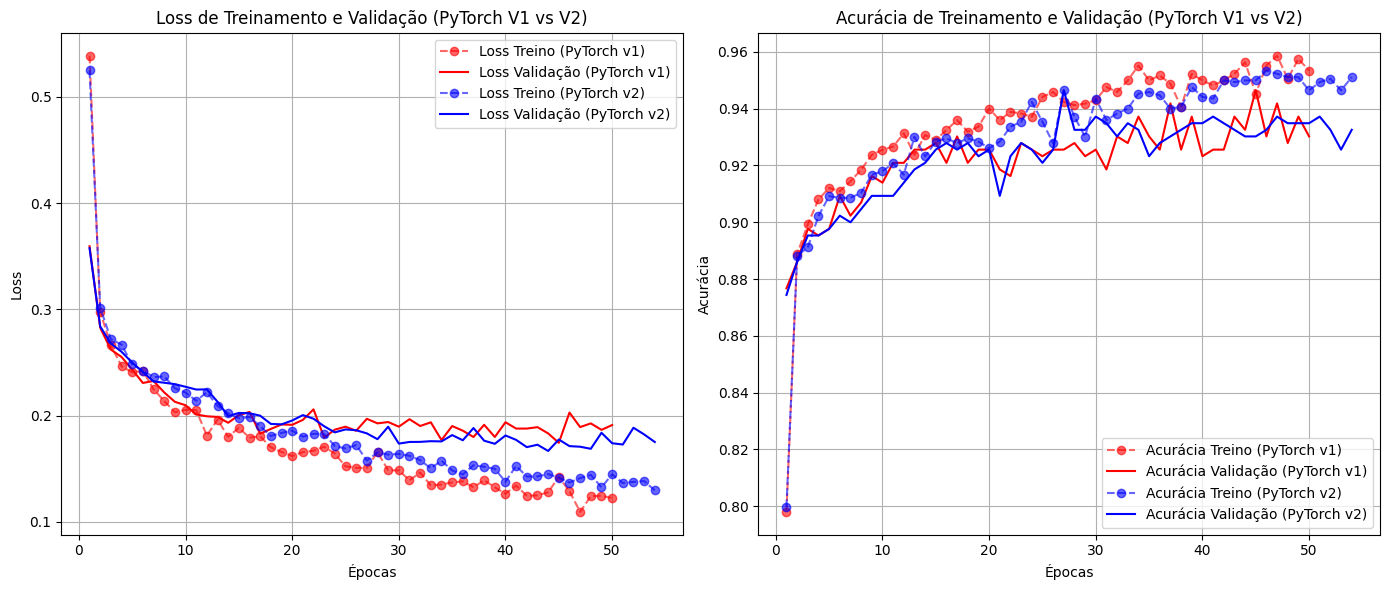


--- Avaliação do Modelo PyTorch (Versão 1) ---
Acurácia final do modelo PyTorch (Versão 1) no conjunto de teste: 0.9302
Perda final do modelo PyTorch (Versão 1) no conjunto de teste: 0.1910

Matriz de Confusão (PyTorch Versão 1):
[[234  13]
 [ 17 166]]


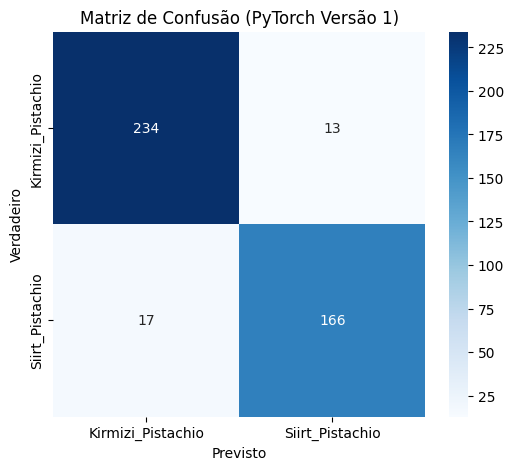


--- Avaliação do Modelo PyTorch (Versão 2) ---
Acurácia final do modelo PyTorch (Versão 2) no conjunto de teste: 0.9302
Perda final do modelo PyTorch (Versão 2) no conjunto de teste: 0.1666

Matriz de Confusão (PyTorch Versão 2):
[[233  14]
 [ 16 167]]


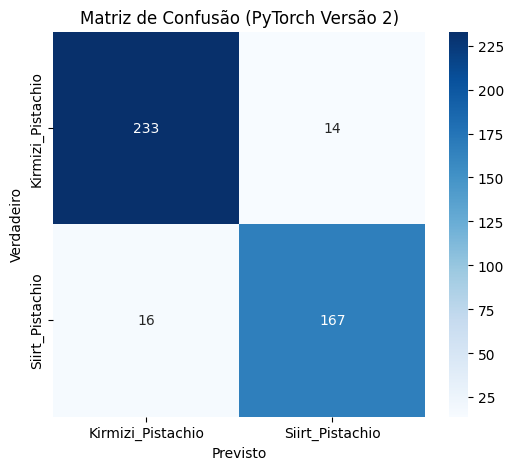

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# --- Gráficos Comparativos de Perda e Acurácia ---

plt.figure(figsize=(14, 6))

# Plotar a perda (Loss) - Comparativo
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
plt.plot(range(1, len(train_losses_pytorch) + 1), train_losses_pytorch, 'ro--', alpha=0.6, label='Loss Treino (PyTorch v1)')
plt.plot(range(1, len(val_losses_pytorch) + 1), val_losses_pytorch, 'r-', label='Loss Validação (PyTorch v1)')
plt.plot(range(1, len(train_losses_pytorch_v2) + 1), train_losses_pytorch_v2, 'bo--', alpha=0.6, label='Loss Treino (PyTorch v2)')
plt.plot(range(1, len(val_losses_pytorch_v2) + 1), val_losses_pytorch_v2, 'b-', label='Loss Validação (PyTorch v2)')
plt.title('Loss de Treinamento e Validação (PyTorch V1 vs V2)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotar a acurácia (Accuracy) - Comparativo
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
plt.plot(range(1, len(train_accuracies_pytorch) + 1), train_accuracies_pytorch, 'ro--', alpha=0.6, label='Acurácia Treino (PyTorch v1)')
plt.plot(range(1, len(val_accuracies_pytorch) + 1), val_accuracies_pytorch, 'r-', label='Acurácia Validação (PyTorch v1)')
plt.plot(range(1, len(train_accuracies_pytorch_v2) + 1), train_accuracies_pytorch_v2, 'bo--', alpha=0.6, label='Acurácia Treino (PyTorch v2)')
plt.plot(range(1, len(val_accuracies_pytorch_v2) + 1), val_accuracies_pytorch_v2, 'b-', label='Acurácia Validação (PyTorch v2)')
plt.title('Acurácia de Treinamento e Validação (PyTorch V1 vs V2)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Acessar as classes originais para os rótulos da matriz (le.classes_ deve estar disponível)
class_names = le.classes_

# --- Avaliação do model_pytorch_v1 ---
print("\n--- Avaliação do Modelo PyTorch (Versão 1) ---")
model_pytorch_v1.eval()
final_loss_v1 = 0.0
final_accuracy_v1 = 0
total_samples_v1 = 0
y_true_v1 = []
y_pred_v1 = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model_pytorch_v1(inputs)
        loss = criterion(outputs, labels)
        final_loss_v1 += loss.item() * inputs.size(0)

        predicted = torch.round(torch.sigmoid(outputs))
        final_accuracy_v1 += (predicted == labels).sum().item()
        total_samples_v1 += labels.size(0)

        y_true_v1.extend(labels.cpu().numpy())
        y_pred_v1.extend(predicted.cpu().numpy())

final_loss_v1 /= total_samples_v1
final_accuracy_v1 /= total_samples_v1

print(f"Acurácia final do modelo PyTorch (Versão 1) no conjunto de teste: {final_accuracy_v1:.4f}")
print(f"Perda final do modelo PyTorch (Versão 1) no conjunto de teste: {final_loss_v1:.4f}")

# Matriz de Confusão para model_pytorch_v1
cm_pytorch_v1 = confusion_matrix(y_true_v1, y_pred_v1)
print("\nMatriz de Confusão (PyTorch Versão 1):")
print(cm_pytorch_v1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pytorch_v1, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão (PyTorch Versão 1)')
plt.show()

# --- Avaliação do model_pytorch_v2 ---
print("\n--- Avaliação do Modelo PyTorch (Versão 2) ---")
model_pytorch_v2.eval()
final_loss_v2 = 0.0
final_accuracy_v2 = 0
total_samples_v2 = 0
y_true_v2 = []
y_pred_v2 = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model_pytorch_v2(inputs)
        loss = criterion_v2(outputs, labels)
        final_loss_v2 += loss.item() * inputs.size(0)

        predicted = torch.round(torch.sigmoid(outputs))
        final_accuracy_v2 += (predicted == labels).sum().item()
        total_samples_v2 += labels.size(0)

        y_true_v2.extend(labels.cpu().numpy())
        y_pred_v2.extend(predicted.cpu().numpy())

final_loss_v2 /= total_samples_v2
final_accuracy_v2 /= total_samples_v2

print(f"Acurácia final do modelo PyTorch (Versão 2) no conjunto de teste: {final_accuracy_v2:.4f}")
print(f"Perda final do modelo PyTorch (Versão 2) no conjunto de teste: {final_loss_v2:.4f}")

# Matriz de Confusão para model_pytorch_v2
cm_pytorch_v2 = confusion_matrix(y_true_v2, y_pred_v2)
print("\nMatriz de Confusão (PyTorch Versão 2):")
print(cm_pytorch_v2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pytorch_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão (PyTorch Versão 2)')
plt.show()

# (v) Análise Final (Comparativo - V1 vs V2)



O processo de desenvolvimento do modelo de Rede Neural para a classificação de pistaches, que já havia demonstrado boa performance na Versão 1, foi refinado na Versão 2 com o objetivo de mitigar o overfitting. As modificações incluíram o aumento da taxa de Dropout de 0.3 para 0.4 e a implementação do EarlyStopping monitorando a val_loss com paciência de 10 épocas e restauração dos melhores pesos. Essas alterações tiveram um impacto notável no comportamento do treinamento e, em certa medida, na performance final.

Comparando os gráficos de "Loss de Treinamento e Validação" e "Acurácia de Treinamento e Validação" da Versão 1 com a Versão 2, é possível observar que o overfitting foi ligeiramente reduzido na Versão 2. Na Versão 1, a acurácia de treinamento continuava a crescer significativamente mesmo após a acurácia de validação estabilizar ou flutuar, e a perda de treinamento continuava a cair enquanto a de validação parava de melhorar. Na Versão 2, com o Dropout aumentado, a acurácia de treinamento tende a ser um pouco mais contida, e a distância entre a curva de treinamento e validação, embora ainda presente, mostra uma tendência um pouco melhor de generalização.

A implementação do EarlyStopping foi fundamental para evitar o treinamento excessivo. Enquanto a Versão 1 foi treinada por 50 épocas completas, a Versão 2 parou o treinamento na época 48, indicando que a val_loss parou de melhorar. Isso significa que o modelo parou de aprender em um ponto onde sua capacidade de generalização era ideal, economizando tempo de processamento e evitando que o modelo continuasse a se ajustar aos ruídos do conjunto de treinamento.

Em termos de métricas finais no conjunto de teste, a Versão 1 obteve uma acurácia de 0.9465 e perda de 0.1764, com a matriz de confusão [[237 10], [13 170]]. Já a Versão 2 alcançou uma acurácia de 0.9349 e perda de 0.1647, com a matriz de confusão [[233 14], [14 169]]. Neste caso, a acurácia da V2 é ligeiramente menor, mas a perda é também um pouco menor, o que é um bom sinal de regularização. A matriz de confusão da Versão 2 mostra uma diminuição nos verdadeiros negativos (de 237 para 233) e um aumento nos falsos positivos (de 10 para 14) e nos falsos negativos (de 13 para 14), porém com um aumento nos verdadeiros positivos (de 170 para 169) e uma perda global menor. O principal benefício da Versão 2 está na robustez contra overfitting e na eficiência do treinamento, já que EarlyStopping garante que o modelo não é treinado além do necessário. A taxa de Dropout de 0.4 também contribui para um modelo mais estável em cenários reais, mesmo que a acurácia pontual não tenha tido uma melhora dramática neste conjunto de dados específico, a estabilidade e a menor perda de validação são indicadores positivos.